# Supervised Learning mit dem Fussballer-Datensatz

Dieses Notebook zeigt einen einfachen **Supervised-Learning-Workflow** ohne dass Sie den Algorithmus selbst programmieren müssen:

1. CSV-Datei hochladen
2. Zielvariable festlegen
3. Trainings- und Testdaten aufteilen
4. Lineare Regression trainieren
5. Vorhersagen auf Testdaten erzeugen
6. Modellgüte bewerten


In [23]:
# 1. Datei hochladen
from google.colab import files
uploaded = files.upload()


Saving players.csv to players (1).csv


In [24]:
# 2. Daten einlesen und ansehen
import io
import pandas as pd

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# typische Index-Spalte entfernen, falls vorhanden
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print('Datensatz:', filename)
print('Zeilen und Spalten:', df.shape)
display(df.head())


Datensatz: players (1).csv
Zeilen und Spalten: (10350, 22)


,name,age,height,ambidextrous,position,marketvalue,team,competition,season,minsTotal,...,passingPerc,dribblePerc,duelAerialPerc,tacklingPerc,foulsPerGame,yellowCard,redCard,wikipedia,google,youtube
0,<c1>d<e1>m Szalai,23,193,0,Forward,3000000.0,Mainz 05,Bundesliga,2010,1293,...,0.689895,0.416667,0.424242,0.823529,1.550000,1,0,11.201579,0.000000,5.164786
1,<c1>d<e1>m Szalai,24,193,0,Forward,3000000.0,Mainz 05,Bundesliga,2011,1083,...,0.666667,0.512821,0.350000,0.454545,1.466667,2,1,10.326891,0.000000,5.525453
2,<c1>d<e1>m Szalai,25,193,0,Forward,7000000.0,Mainz 05,Bundesliga,2012,2412,...,0.667925,0.409091,0.329949,0.642857,1.724138,6,0,11.712931,2.233592,5.814131
3,<c1>d<e1>m Szalai,26,193,0,Forward,7000000.0,Schalke 04,Bundesliga,2013,1423,...,0.668639,0.666667,0.384146,0.347826,1.500000,2,0,11.119008,0.000000,6.182085
4,<c1>kos Buzs<e1>ky,29,180,0,Midfielder,1000000.0,Queens Park Rangers,Premier League,2011,896,...,0.837607,0.500000,0.250000,0.750000,0.666667,0,0,11.196967,1.474785,3.433987


## Zielvariable und Features

Beim Advertising-Datensatz ist **sales** die Zielvariable $y$.
Die Eingabevariablen $X$ sind **TV, radio und newspaper**.

In [32]:
# 3. Zielvariable und Features festlegen
TARGET = 'marketvalue'

# Nur numerische Features verwenden
X = df[['age']]
y = df[TARGET]

print('Features X:', list(X.columns))
print('Zielvariable y:', TARGET)


Features X: ['age']
Zielvariable y: marketvalue


In [33]:
# 4. Daten in Training (80 %) und Test (20 %) aufteilen
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training:', len(X_train), 'Beobachtungen')
print('Test:', len(X_test), 'Beobachtungen')


Training: 8280 Beobachtungen
Test: 2070 Beobachtungen


In [34]:
# 5. Lineare Regression trainieren
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept:', round(model.intercept_, 4))
print('\nKoeffizienten:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'{feature}: {coef:.4f}')


Intercept: 10561590.8505

Koeffizienten:
age: -192802.3800


In [35]:
# 6. Vorhersagen für bisher nicht verwendete Testdaten
y_pred = model.predict(X_test)

results = X_test.copy()
results['sales_tatsaechlich'] = y_test.values
results['sales_vorhergesagt'] = y_pred
results['fehler'] = results['sales_tatsaechlich'] - results['sales_vorhergesagt']

display(results.head(10).round(2))


,age,sales_tatsaechlich,sales_vorhergesagt,fehler
10295,24,9000000.0,5934333.73,3065666.27
7747,28,8000000.0,5163124.21,2836875.79
8553,24,2000000.0,5934333.73,-3934333.73
7191,35,1000000.0,3813507.55,-2813507.55
500,23,3700000.0,6127136.11,-2427136.11
8109,21,16000000.0,6512740.87,9487259.13
3777,27,750000.0,5355926.59,-4605926.59
3885,29,1500000.0,4970321.83,-3470321.83
3721,30,4000000.0,4777519.45,-777519.45
119,25,8000000.0,5741531.35,2258468.65


In [36]:
# 7. Modellgüte bewerten
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R²   = {r2:.3f}')
print(f'MAE  = {mae:.3f}')
print(f'RMSE = {rmse:.3f}')


R²   = 0.014
MAE  = 4990295.775
RMSE = 8555249.496


**Interpretation:**

- **R²**: Welcher Anteil der Streuung von `sales` wird vom Modell erklärt?
- **MAE**: durchschnittlicher absoluter Vorhersagefehler
- **RMSE**: bestraft größere Vorhersagefehler stärker


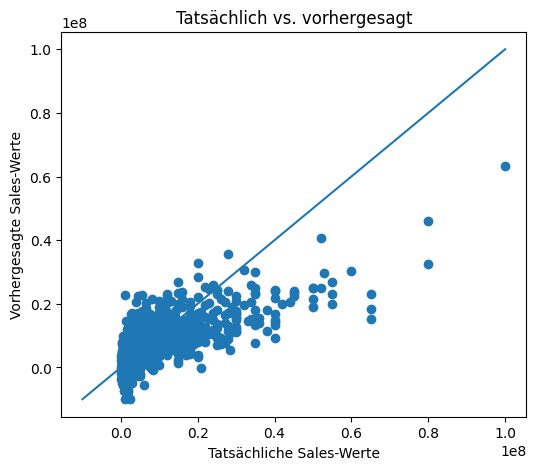

In [31]:
# 8. Tatsächliche und vorhergesagte Werte vergleichen
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred)
plt.xlabel('Tatsächliche Sales-Werte')
plt.ylabel('Vorhergesagte Sales-Werte')
plt.title('Tatsächlich vs. vorhergesagt')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()


## Reflexionsfragen

1. Was sind in diesem Beispiel die **Features X** und die **Zielvariable y**?
2. Warum handelt es sich um **Supervised Learning**?
3. Warum ist dies ein **Regressionsproblem**?
4. Warum trennen wir Trainings- und Testdaten?
5. Welche Variable hat den größten positiven Koeffizienten?
6. Wie gut sagt das Modell neue, bisher nicht zum Training verwendete Beobachtungen voraus?